# Notebook 03: Feature Engineering
## Netflix Content Strategy Analysis

**Business Context**: Raw data columns do not directly answer business questions. Feature engineering creates derived variables that make patterns visible and measurable. This notebook creates all 12 locked engineered features.

**Input**: `data/processed/netflix_cleaned.csv`  
**Output**: `data/processed/netflix_features.csv` + `.parquet` + `netflix_powerbi.csv`

| Feature | Business Purpose |
|---------|------------------|
| `release_decade` | Era-level trend analysis |
| `movie_age` | Catalog freshness analysis |
| `year_added` | Netflix growth timeline |
| `month_added` | Seasonal addition patterns |
| `weekday_added` | Day-of-week patterns |
| `duration_category` | Content length segmentation |
| `primary_genre` | Top-level genre classification |
| `genre_count` | Genre diversity per title |
| `country_count` | Co-production analysis |
| `director_count` | Director collaboration analysis |
| `cast_count` | Cast size analysis |
| `is_movie` | Boolean filter for segmented analysis |

## 0. Setup & Imports

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.config import CLEANED_CSV, FEATURES_CSV, FEATURES_PARQUET, POWERBI_CSV, ensure_dirs
from src.utils import load_csv, save_csv, save_parquet, quick_profile
from src.features import (
    run_feature_pipeline,
    add_release_decade,
    add_movie_age,
    add_date_added_features,
    add_duration_category,
    add_genre_features,
    add_country_count,
    add_cast_director_counts,
    add_is_movie_flag,
    prepare_powerbi_export,
)

ensure_dirs()
print('Setup complete.')

Setup complete.


## 1. Load Cleaned Dataset

In [2]:
df = load_csv(CLEANED_CSV)

# Reconstruct genres list from string (CSV stores it as string)
df['genres'] = df['genres'].apply(
    lambda x: [g.strip() for g in str(x).split(',') if g.strip()] if pd.notna(x) else []
)

# Restore date_added as datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print(f'Loaded cleaned dataset: {df.shape}')
display(df.head(3))

13:01:16 | INFO | Loaded netflix_cleaned.csv: 8,807 rows × 19 cols


Loaded cleaned dataset: (8807, 19)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes,duration_seasons,director_missing,cast_missing,country_missing,rating_missing,genres
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Cast,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90.0,NaN,False,True,False,False,[Documentaries]
1,s2,Tv Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN,2.0,True,False,False,False,"[International TV Shows, TV Dramas, TV Mysteries]"
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN,1.0,False,False,True,False,"[Crime TV Shows, International TV Shows, TV Ac..."


## 2. Feature Engineering — Step by Step

Each feature is created and verified individually.

### Feature 1: `release_decade`

**Business Use**: Group releases by decade for era-level trend analysis (1990s vs 2000s vs 2010s vs 2020s).

In [3]:
df = add_release_decade(df)
print('release_decade distribution:')
print(df['release_decade'].value_counts().sort_index())

13:01:16 | INFO | Added: release_decade


release_decade distribution:
release_decade
1920s       1
1940s      15
1950s      11
1960s      25
1970s      70
1980s     129
1990s     274
2000s     810
2010s    5927
2020s    1545
Name: count, dtype: int64


### Feature 2: `movie_age`

**Business Use**: Measures catalog freshness. A high average movie_age suggests Netflix is relying on older content.

In [4]:
df = add_movie_age(df)
print(f'movie_age stats:')
print(df['movie_age'].describe())

13:01:16 | INFO | Added: movie_age


movie_age stats:
count       8807.0
mean     11.819802
std       8.819312
min            5.0
25%            7.0
50%            9.0
75%           13.0
max          101.0
Name: movie_age, dtype: Float64


### Features 3–5: Date Added Features

**Business Use**: Identify seasonal patterns, day-of-week preferences, and year-over-year growth.

In [5]:
df = add_date_added_features(df)
print('year_added range:', df['year_added'].min(), '–', df['year_added'].max())
print('\nmonth_added distribution:')
print(df['month_added'].value_counts())
print('\nweekday_added distribution:')
print(df['weekday_added'].value_counts())

13:01:16 | INFO | Added: year_added, month_added, weekday_added


year_added range: 2008 – 2021

month_added distribution:
month_added
July         827
December     813
September    770
April        764
October      760
August       755
March        742
January      738
June         728
November     705
May          632
February     563
Name: count, dtype: int64

weekday_added distribution:
weekday_added
Friday       2498
Thursday     1396
Wednesday    1288
Tuesday      1197
Monday        851
Saturday      816
Sunday        751
Name: count, dtype: int64


### Feature 6: `duration_category`

**Business Use**: Segment content by length. Are Netflix movies getting shorter? Do most shows run for only 1 season?

In [6]:
df = add_duration_category(df)
print('Movie duration categories:')
print(df[df['type'] == 'Movie']['duration_category'].value_counts())
print('\nTV Show season categories:')
print(df[df['type'] == 'TV Show']['duration_category'].value_counts())

13:01:16 | INFO | Added: duration_category


Movie duration categories:
duration_category
Medium (90-120)     3092
Short (60-90)       1380
Long (120-180)      1149
Very Short (<60)     458
Very Long (180+)      49
Name: count, dtype: int64

TV Show season categories:
Series([], Name: count, dtype: int64)


### Features 7–8: Genre Features

**Business Use**: `primary_genre` enables single-dimension genre analysis. `genre_count` measures how Netflix categorizes content.

In [7]:
df = add_genre_features(df)
print('Top 10 primary genres:')
print(df['primary_genre'].value_counts().head(10))
print(f'\ngenre_count stats:')
print(df['genre_count'].describe())

13:01:16 | INFO | Added: primary_genre, genre_count


Top 10 primary genres:
primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       774
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     388
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

genre_count stats:
count      8807.0
mean      2.19405
std      0.784341
min           1.0
25%           2.0
50%           2.0
75%           3.0
max           3.0
Name: genre_count, dtype: Float64


### Feature 9: `country_count`

**Business Use**: Identifies co-productions. Higher country_count may correlate with higher production budgets.

In [8]:
df = add_country_count(df)
print('country_count distribution:')
print(df['country_count'].value_counts().sort_index())

13:01:16 | INFO | Added: country_count


country_count distribution:
country_count
0      831
1     6661
2      869
3      272
4      115
5       36
6       14
7        5
8        2
10       1
12       1
Name: count, dtype: Int64


### Features 10–11: Director & Cast Counts

**Business Use**: Director count identifies collaborative productions. Cast count may correlate with genre (ensemble comedies vs solo dramas).

In [9]:
df = add_cast_director_counts(df)
print(f'director_count stats:')
print(df['director_count'].describe())
print(f'\ncast_count stats:')
print(df['cast_count'].describe())

13:01:16 | INFO | Added: director_count, cast_count


director_count stats:
count      8807.0
mean     0.792324
std      0.696277
min           0.0
25%           0.0
50%           1.0
75%           1.0
max          13.0
Name: director_count, dtype: Float64

cast_count stats:
count      8807.0
mean     7.281254
std      4.862244
min           0.0
25%           4.0
50%           8.0
75%          10.0
max          50.0
Name: cast_count, dtype: Float64


### Feature 12: `is_movie`

**Business Use**: Boolean flag for filtering — enables clean segmentation in all downstream analyses.

In [10]:
df = add_is_movie_flag(df)
print(f'is_movie: {df["is_movie"].sum():,} Movies | {(~df["is_movie"]).sum():,} TV Shows')

13:01:16 | INFO | Added: is_movie


is_movie: 6,131 Movies | 2,676 TV Shows


## 3. Final Feature Dataset Overview

In [11]:
print('=== FEATURE DATASET SUMMARY ===')
quick_profile(df)
engineered = ['release_decade','movie_age','year_added','month_added','weekday_added',
              'duration_category','primary_genre','genre_count','country_count',
              'director_count','cast_count','is_movie']
print(f'\nEngineered features ({len(engineered)}):')
display(df[engineered].head(5))

=== FEATURE DATASET SUMMARY ===
──────────────────────────────────────────────────
Shape          : 8,807 rows × 31 columns


Memory usage   : 12.32 MB
Missing cells  : 11,532


Duplicate rows : 0
──────────────────────────────────────────────────
show_id                      object
type                         object
title                        object
director                     object
cast                         object
country                      object
date_added           datetime64[ns]
release_year                  int64
rating                       object
duration                     object
listed_in                    object
description                  object
duration_minutes            float64
duration_seasons            float64
director_missing               bool
cast_missing                   bool
country_missing                bool
rating_missing                 bool
genres                       object
release_decade               object
movie_age                     Int64
year_added                    Int64
month_added                  object
weekday_added                object
duration_category            object
primary_genre                o

,release_decade,movie_age,year_added,month_added,weekday_added,duration_category,primary_genre,genre_count,country_count,director_count,cast_count,is_movie
0,2020s,6,2021,September,Saturday,Medium (90-120),Documentaries,1,1,1,0,True
1,2020s,5,2021,September,Friday,<NA>,International TV Shows,3,1,0,19,False
2,2020s,5,2021,September,Friday,<NA>,Crime TV Shows,3,0,1,9,False
3,2020s,5,2021,September,Friday,<NA>,Docuseries,2,0,0,0,False
4,2020s,5,2021,September,Friday,<NA>,International TV Shows,3,1,0,8,False


## 4. Feature Distributions — Quick Visual Check

13:01:16 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


13:01:16 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


13:01:16 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


13:01:16 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


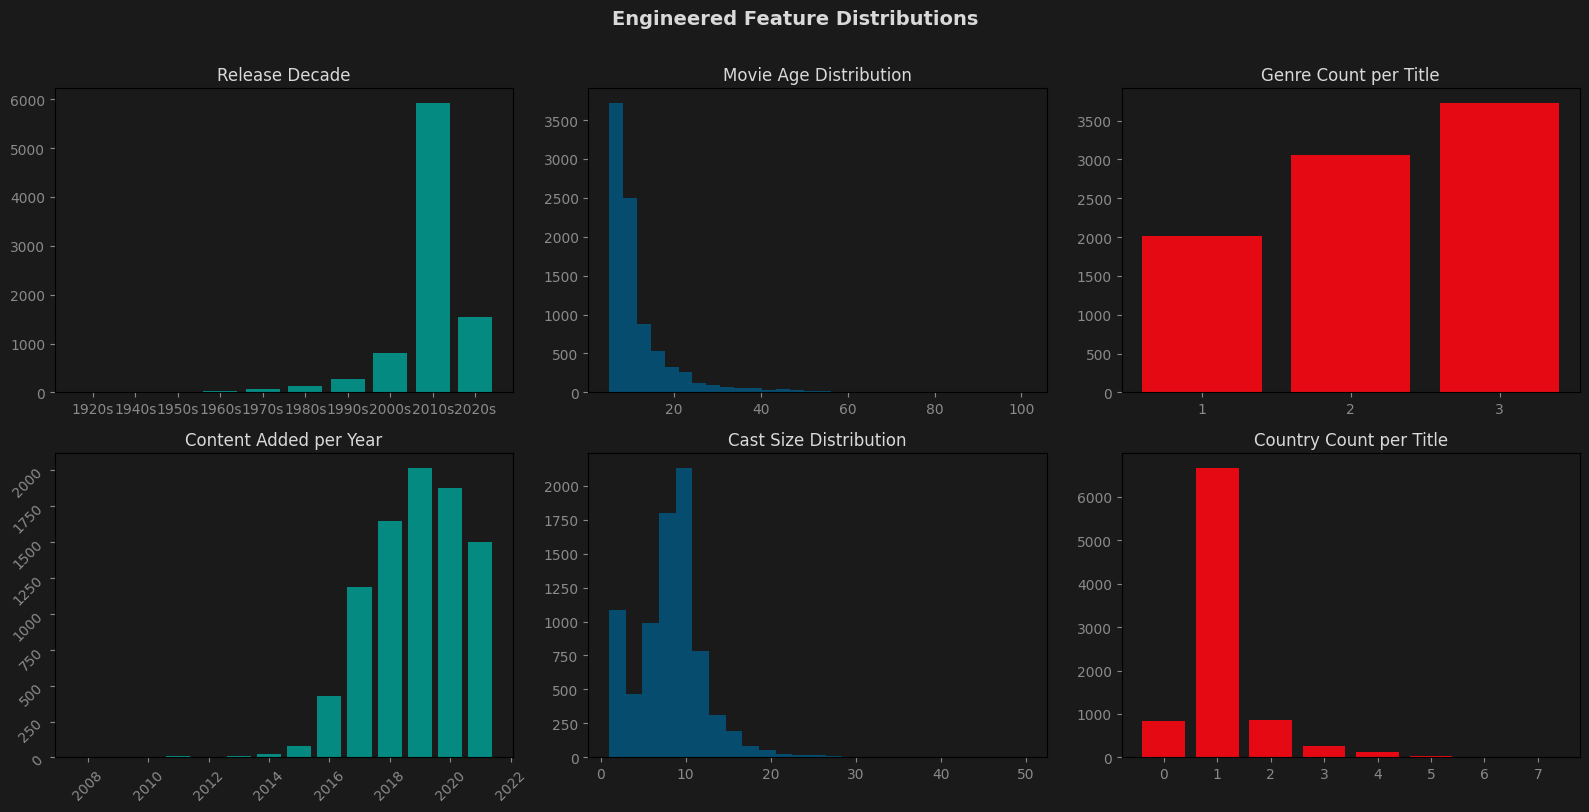

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor('#1A1A1A')

# release_decade
d = df[df['release_decade'] != 'Unknown']['release_decade'].value_counts().sort_index()
axes[0,0].bar(d.index, d.values, color='#048A81')
axes[0,0].set_title('Release Decade', color='#D9D9D9')
axes[0,0].set_facecolor('#1A1A1A')
axes[0,0].tick_params(colors='#8A8A8A')

# movie_age histogram
axes[0,1].hist(df['movie_age'].dropna(), bins=30, color='#054C6E')
axes[0,1].set_title('Movie Age Distribution', color='#D9D9D9')
axes[0,1].set_facecolor('#1A1A1A')
axes[0,1].tick_params(colors='#8A8A8A')

# genre_count
d2 = df['genre_count'].value_counts().sort_index()
axes[0,2].bar(d2.index.astype(str), d2.values, color='#E50914')
axes[0,2].set_title('Genre Count per Title', color='#D9D9D9')
axes[0,2].set_facecolor('#1A1A1A')
axes[0,2].tick_params(colors='#8A8A8A')

# year_added
d3 = df.dropna(subset=['year_added']).groupby('year_added').size()
axes[1,0].bar(d3.index, d3.values, color='#048A81')
axes[1,0].set_title('Content Added per Year', color='#D9D9D9')
axes[1,0].set_facecolor('#1A1A1A')
axes[1,0].tick_params(colors='#8A8A8A', rotation=45)

# cast_count
axes[1,1].hist(df[df['cast_count'] > 0]['cast_count'], bins=25, color='#054C6E')
axes[1,1].set_title('Cast Size Distribution', color='#D9D9D9')
axes[1,1].set_facecolor('#1A1A1A')
axes[1,1].tick_params(colors='#8A8A8A')

# country_count
d4 = df['country_count'].value_counts().sort_index().head(8)
axes[1,2].bar(d4.index.astype(str), d4.values, color='#E50914')
axes[1,2].set_title('Country Count per Title', color='#D9D9D9')
axes[1,2].set_facecolor('#1A1A1A')
axes[1,2].tick_params(colors='#8A8A8A')

plt.suptitle('Engineered Feature Distributions', fontsize=14,
             fontweight='bold', color='#D9D9D9', y=1.01)
plt.tight_layout()
plt.show()

## 5. Export Feature Dataset

In [13]:
# CSV export (genres as string)
df_csv = df.copy()
df_csv['genres'] = df_csv['genres'].apply(
    lambda g: ', '.join(g) if isinstance(g, list) else ''
)
save_csv(df_csv, FEATURES_CSV)

# Parquet export (genres as string for compatibility)
df_parquet = df.copy()
df_parquet['genres'] = df_parquet['genres'].apply(
    lambda g: ', '.join(g) if isinstance(g, list) else ''
)
save_parquet(df_parquet, FEATURES_PARQUET)

# Power BI export
df_pbi = prepare_powerbi_export(df)
df_pbi['genres'] = df_pbi['genres'].apply(
    lambda g: ', '.join(g) if isinstance(g, list) else ''
)
save_csv(df_pbi, POWERBI_CSV)

print('All exports complete!')
print(f'  Features CSV   → {FEATURES_CSV}')
print(f'  Features Parquet → {FEATURES_PARQUET}')
print(f'  Power BI CSV   → {POWERBI_CSV}')

13:01:17 | INFO | Saved CSV  → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_features.csv  (8,807 rows)


13:01:17 | INFO | Saved Parquet → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_features.parquet  (8,807 rows)


13:01:17 | INFO | Saved CSV  → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_powerbi.csv  (8,807 rows)


All exports complete!
  Features CSV   → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_features.csv
  Features Parquet → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_features.parquet
  Power BI CSV   → D:\DataAnalyst\Netflix-Content-Strategy-Analysis\data\processed\netflix_powerbi.csv


## 6. Summary

All 12 engineered features have been created and verified. The dataset is now ready for exploratory analysis.

**Next Step**: Proceed to `04_exploratory_analysis.ipynb` to answer the 10 business questions.